
--- raw.info summary ---
{'ch_names_count': 46,
 'duration_s (approx)': np.float64(568.0),
 'n_channels': 46,
 'sfreq': 256.0}

--- full raw.info ---
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, F7, T3, T5, O1, F3, C3, P3, A1, Fz, Cz, Fp2, F8, T4, T6, ...
 chs: 46 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2025-05-10 18:55:25 UTC
 nchan: 46
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, first_name: X, last_name: X>
>

Detected channel name lists (heuristic):
  EOG candidates: ['LOC1', 'LOC2']
  ECG candidates: ['EKGL', 'EKGR']
  EMG candidates: ['EMG1', 'EMG2']
  MISC candidates (some): ['X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18']

First 20 channel names: ['Fp1', 'F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 'A1', 'Fz', 'Cz', 'Fp2', 'F8', 'T4', 'T6', 'O2', 'F4', 'C4', 'P4', 'A2']
Using matplotlib as 2D backend.


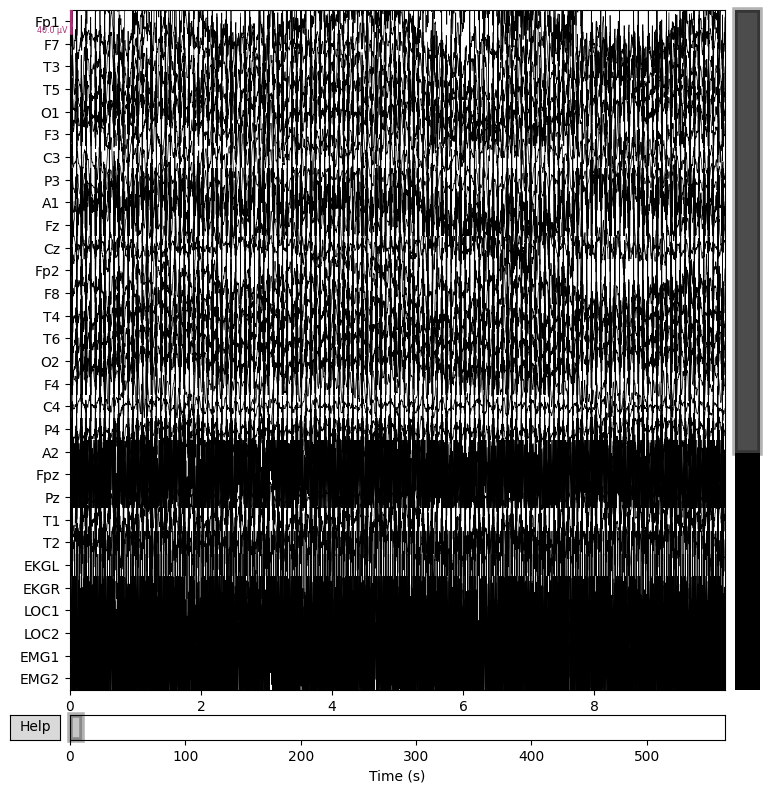

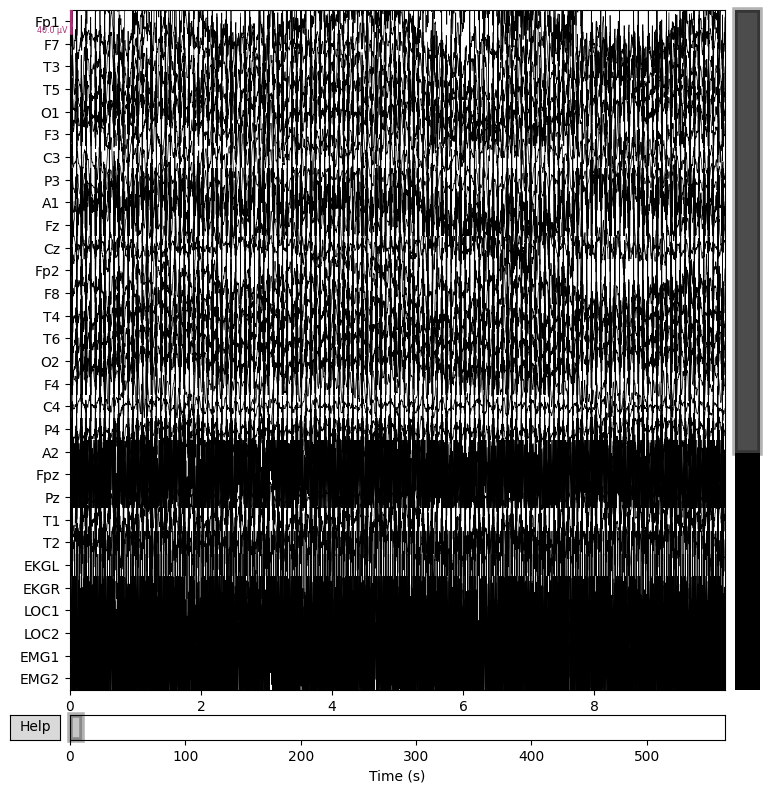

In [1]:
# %% Step 1: Load & inspect
import mne
import pprint

fname = "../data/XU/XUAWAKE7.EDF"  # change path if needed

# --- Load (preload=True so later operations are faster) ---
raw = mne.io.read_raw_edf(fname, preload=True, verbose='ERROR')

# --- Print basic info (human readable) ---
print("\n--- raw.info summary ---")
pprint.pprint({
    "sfreq": raw.info['sfreq'],
    "n_channels": raw.info['nchan'],
    "ch_names_count": len(raw.ch_names),
    "duration_s (approx)": raw.n_times / raw.info['sfreq']
})

print("\n--- full raw.info ---")
print(raw.info)   # prints channel types, etc.

# --- Show channel name groups by heuristic patterns ---
ch = raw.ch_names
eog_candidates = [c for c in ch if any(x in c.upper() for x in ('EOG','LOC','VEOG','HEOG'))]
ecg_candidates = [c for c in ch if any(x in c.upper() for x in ('ECG','EKG','EKGL','EKGR','EKG'))]
emg_candidates = [c for c in ch if c.upper().startswith('EMG')]
misc_candidates = [c for c in ch if any(x in c.upper() for x in ('OSAT','PR','DC','X9','X10','X11','X12','X13','X14','X15','X16','X17','X18'))]

print("\nDetected channel name lists (heuristic):")
print("  EOG candidates:", eog_candidates)
print("  ECG candidates:", ecg_candidates)
print("  EMG candidates:", emg_candidates)
print("  MISC candidates (some):", misc_candidates[:10])

# --- Print first 5 channel names for quick glance ---
print("\nFirst 20 channel names:", ch[:20])

# --- Quick optional plot to visually inspect (uncomment to run) ---
raw.plot(n_channels=30, duration=10.0, show=True)


Channels present in raw but MISSING from standard_1020 montage (these will cause errors):
['DC1', 'DC2', 'DC3', 'DC4', 'EKGL', 'EKGR', 'EMG1', 'EMG2', 'LOC1', 'LOC2', 'OSAT', 'PR', 'T1', 'T2', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X9']

A (short) sample of montage channels not in your raw (normal):
['AF1', 'AF10', 'AF2', 'AF3', 'AF4', 'AF5', 'AF6', 'AF7', 'AF8', 'AF9', 'AFz', 'C1', 'C2', 'C5', 'C6', 'CP1', 'CP2', 'CP3', 'CP4', 'CP5']


/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_19427/3693021195.py:19: RuntimeWarning: DigMontage is only a subset of info. There are 24 channel positions not present in the DigMontage. The channels missing from the montage are:

['T1', 'T2', 'EKGL', 'EKGR', 'LOC1', 'LOC2', 'EMG1', 'EMG2', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'DC1', 'DC2', 'DC3', 'DC4', 'OSAT', 'PR'].

Consider using inst.rename_channels to match the montage nomenclature, or inst.set_channel_types if these are not EEG channels, or use the on_missing parameter if the channel positions are allowed to be unknown in your analyses.
  raw.set_montage(montage, match_case=False, on_missing='warn')


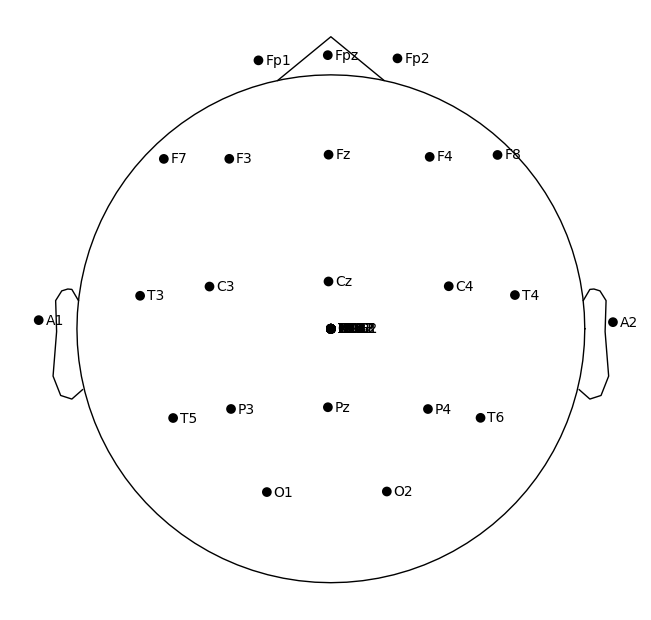


Done. If any channels were missing from the montage they were listed above.


In [2]:
# %% Fix montage error and show sensor layout (Step 2.1)
import mne

# assume `raw` is already loaded from Step 1
montage = mne.channels.make_standard_montage('standard_1020')

# show which of your channels are NOT present in the montage
montage_names = set(montage.ch_names)
raw_names = set(raw.ch_names)
missing_in_montage = sorted(list(raw_names - montage_names))
missing_in_info = sorted(list(montage_names - raw_names))[:20]  # a sample if many

print("Channels present in raw but MISSING from standard_1020 montage (these will cause errors):")
print(missing_in_montage)
print("\nA (short) sample of montage channels not in your raw (normal):")
print(missing_in_info)

# Set montage but allow missing channel positions (warn instead of error)
raw.set_montage(montage, match_case=False, on_missing='warn')

# Quick sensor layout (will place those with known montage positions)
raw.plot_sensors(kind='topomap', show_names=True)

# Print a short confirmation for copy/paste
print("\nDone. If any channels were missing from the montage they were listed above.")


In [5]:
import mne

# Robust import logic
try:
    from mne.preprocessing import annotate_muscle_zscore
except ImportError:
    from mne.preprocessing.annotate import annotate_muscle_zscore

try:
    from mne.preprocessing import annotate_flat
except ImportError:
    # define lightweight fallback if missing
    import numpy as np
    def annotate_flat(raw, picks="eeg", flat=1e-6):
        """Simple flat-segment detector (variance-based)."""
        picks = mne.pick_types(raw.info, eeg=True)
        data = raw.get_data(picks=picks)
        sfreq = raw.info['sfreq']
        win = int(2 * sfreq)
        onsets, durations, desc = [], [], []
        for ch_i, ch in enumerate([raw.ch_names[p] for p in picks]):
            sig = data[ch_i]
            for i in range(0, len(sig) - win, win):
                seg = sig[i:i+win]
                if np.var(seg) < flat**2:
                    onsets.append(i / sfreq)
                    durations.append(win / sfreq)
                    desc.append(f"BAD_flat_{ch}")
        return mne.Annotations(onsets, durations, desc)


In [9]:
raw_filtered = raw.copy()
raw_filtered.load_data()
raw_filtered.filter(1.0, 40.0, fir_design="firwin", verbose="ERROR")

print("Plotting PSD (0–50 Hz). Close the figure to continue.")
raw_filtered.plot_psd(fmax=50.0, average=True)

annot_flat = annotate_flat(raw_filtered, picks="eeg", flat=1e-6)

annot_muscle, muscle_scores = annotate_muscle_zscore(
    raw_filtered,
    threshold=4.0,
    min_length_good=0.2,
    filter_freq=(110, 120),
)

combined_annots = annot_flat + annot_muscle
raw_filtered.set_annotations(combined_annots)

print("Plotting filtered raw (10 s window).")
raw_filtered.plot(n_channels=30, duration=10.0, start=0.0, show=True)

total_annot_seconds = sum(a["duration"] for a in raw_filtered.annotations)
print("\nAnnotations summary:")
print(f"  Number of annotations: {len(raw_filtered.annotations)}")
print(f"  Total annotated time (s): {total_annot_seconds:.1f}")
print("  First 5 annotations:", list(raw_filtered.annotations)[:5])

Plotting PSD (0–50 Hz). Close the figure to continue.
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).
Using eeg sensors for muscle artifact detection
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1.1e+02 - 1.2e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 110.00
- Lower transition bandwidth: 27.50 Hz (-6 dB cutoff frequency: 96.25 Hz)
- Upper passband edge: 120.00 Hz
- Upper transition bandwidth: 8.00 Hz (-6 dB cutoff frequency: 124.00 Hz)
- Filter length: 107 samples (0.418 s)



/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_19427/4217877917.py:6: UserWarning: Zero value in spectrum for channels OSAT, PR
  raw_filtered.plot_psd(fmax=50.0, average=True)
/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_19427/4217877917.py:6: UserWarning: Infinite value in PSD for channels OSAT, PR.
These channels might be dead.
  raw_filtered.plot_psd(fmax=50.0, average=True)
/Users/wanghley/Workspace/Projects/ML-driven EEG biomarkers/.venv/lib/python3.13/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


Setting up low-pass filter at 4 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 4.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 5.00 Hz)
- Filter length: 423 samples (1.652 s)



ValueError: orig_time should be the same to add/concatenate 2 annotations (got None != 2025-05-10 18:55:25+00:00)

In [ ]:
from mne.preprocessing import annotate_muscle, annotate_flat